In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import glob as gb
import tqdm
import tensorflow as tf

tf.config.run_functions_eagerly(True)

In [3]:
cd /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/Car

/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/Car


In [4]:
postion=pd.read_csv('train_solution_bounding_boxes (1).csv')

In [5]:
postion.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [ ]:
postion.shape

(559, 5)

In [ ]:
len(postion)

559

In [6]:
#loading data and resize it and collect it in one folder

trainpath = 'training_images/'
new_size=224
X_train = []
y_train = []


for i in tqdm.tqdm(range(len(postion))):
    orignal_image = cv2.imread(trainpath+postion.iloc[i,0])
    image = cv2.cvtColor(orignal_image, cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image , (new_size,new_size))
    X_train.append(resized_image)
print('image reading ...finished')
print('--------------------------------------------------')


100%|██████████| 559/559 [05:17<00:00,  1.76it/s]

image reading ...finished
--------------------------------------------------


In [7]:
X_train=np.array(X_train)

In [8]:
X_train.shape

(559, 224, 224, 3)

In [9]:
img = cv2.imread(trainpath+str(postion.iloc[0,0]))
img.shape

(380, 676, 3)

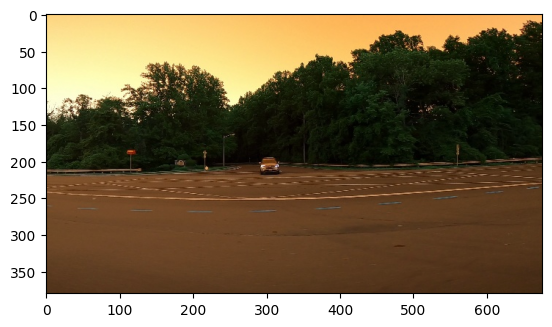

In [10]:
plt.imshow(img)

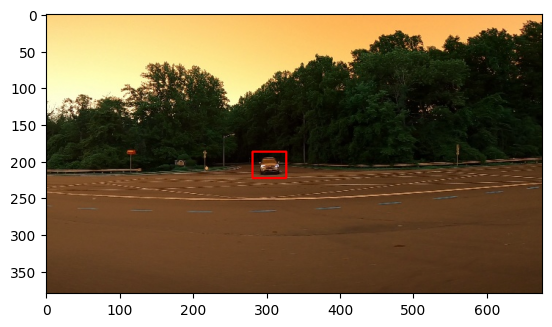

In [11]:
img=cv2.rectangle(img,(int(postion['xmin'][0]),int(postion['ymin'][0])), (int(postion['xmax'][0]),int(postion['ymax'][0])) , (255,0,0),2)
plt.imshow(img)

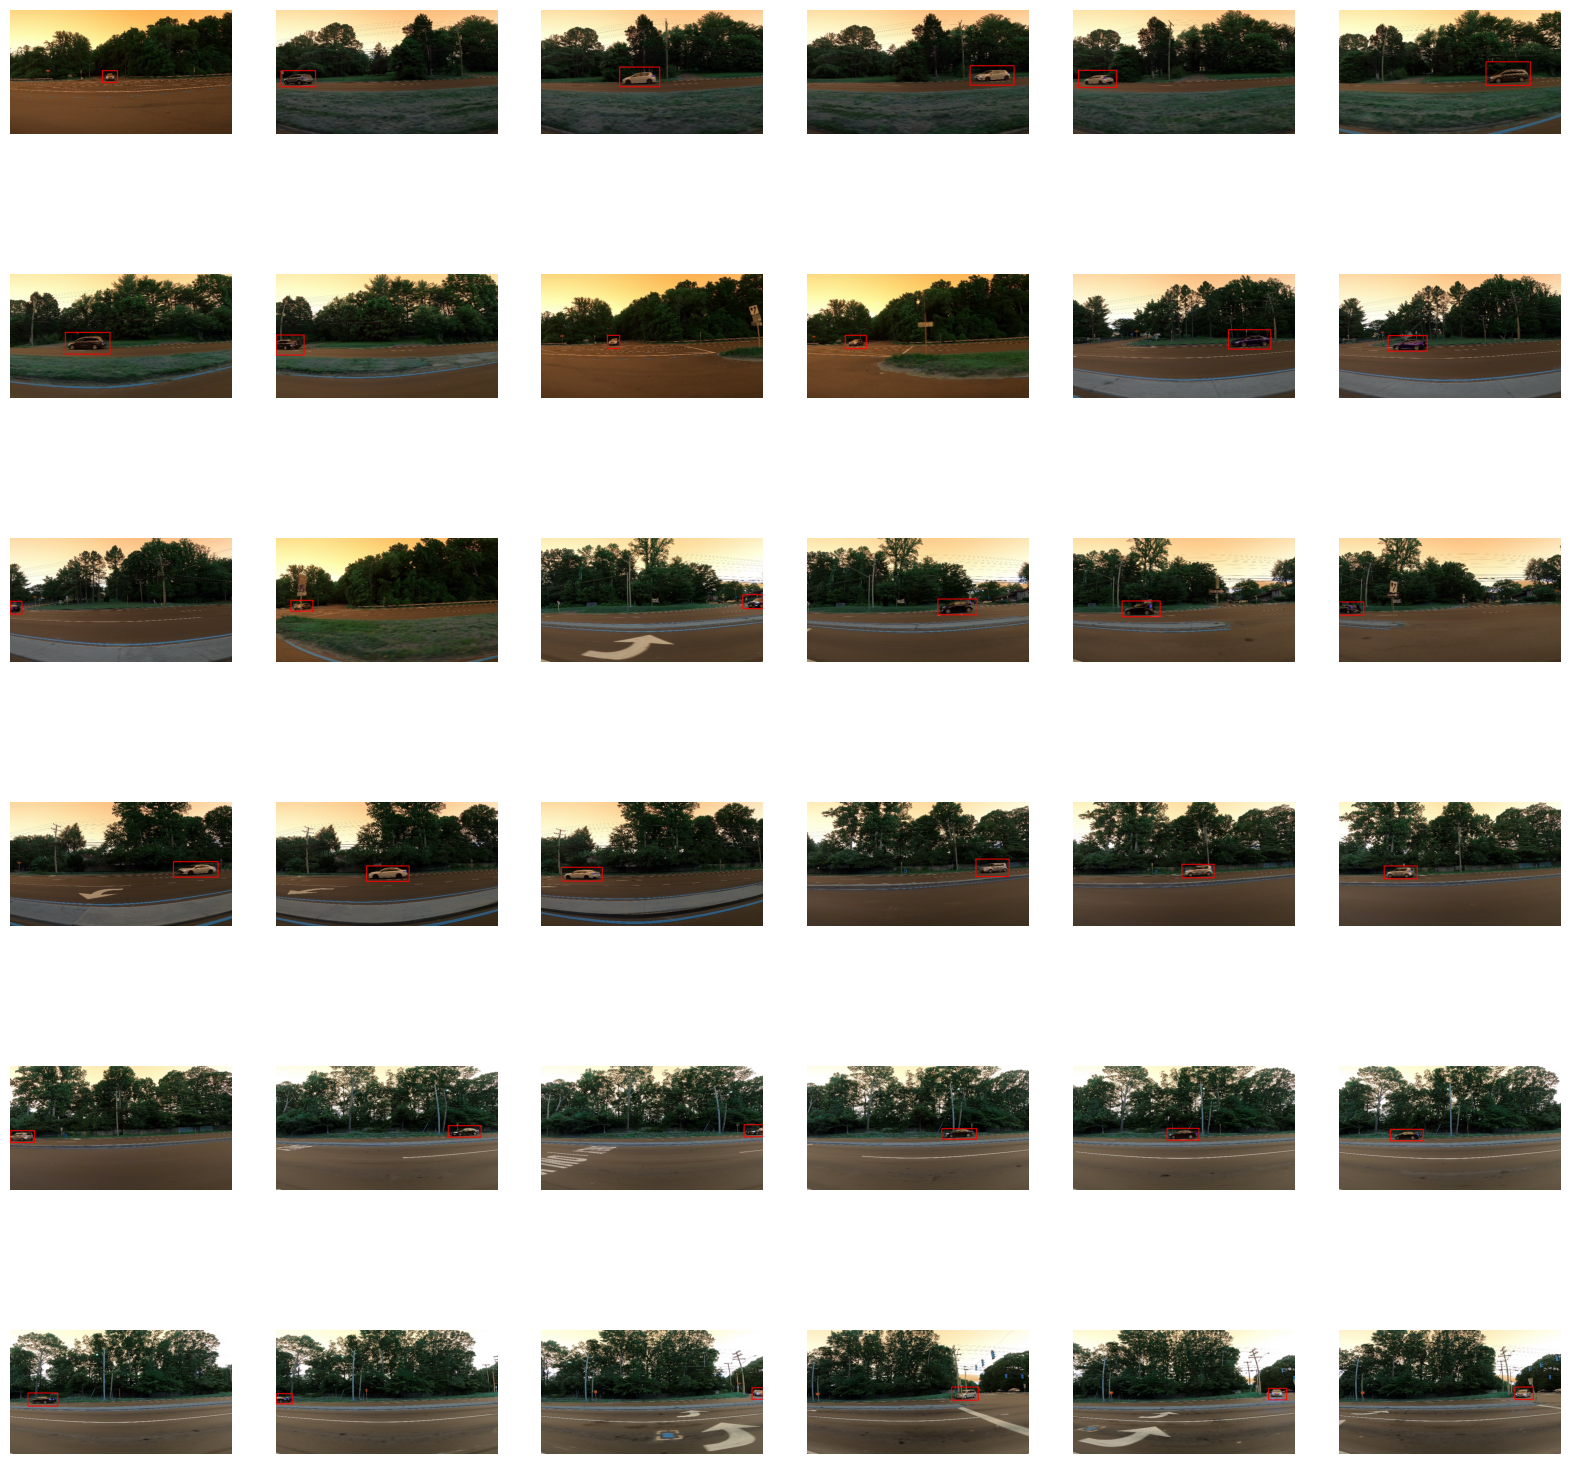

In [12]:
#showing training images with labels
plt.figure(figsize=(20,20))
for n , i in enumerate(range(36)) :
    plt.subplot(6,6,n+1)
    img = cv2.imread(trainpath+str(postion.iloc[i,0]))
    img=cv2.rectangle(img,(int(postion['xmin'][i]),int(postion['ymin'][i])), (int(postion['xmax'][i]),int(postion['ymax'][i])) , (255,0,0),2)
    plt.imshow(img)
    plt.axis('off')

In [13]:
# Ensure 'postion' is in its original state with the 'image' column
postion = pd.read_csv('train_solution_bounding_boxes (1).csv')

original_widths = []
original_heights = []
for img_name in postion['image']:
    original_img = cv2.imread(trainpath + img_name)
    h, w, _ = original_img.shape
    original_heights.append(h)
    original_widths.append(w)

postion['width'] = original_widths
postion['height'] = original_heights

# Using .loc to avoid SettingWithCopyWarning
postion.loc[:, "xmin"] = postion["xmin"] * new_size / postion["width"]
postion.loc[:, "xmax"] = postion["xmax"] * new_size / postion["width"]
postion.loc[:, "ymin"] = postion["ymin"] * new_size / postion["height"]
postion.loc[:, "ymax"] = postion["ymax"] * new_size / postion["height"]

# Create the target DataFrame for the model, which only contains the bounding box coordinates
bbox_targets = postion[['xmin', 'ymin', 'xmax', 'ymax']]


In [14]:
#postion=postion.astype('int32')
#postion.drop(['width','height'],axis=1,inplace=True)
postion.head()

,image,xmin,ymin,xmax,ymax,width,height
0,vid_4_1000.jpg,93.198263,110.252252,108.596237,131.585586,676,380
1,vid_4_10000.jpg,5.024602,110.252252,39.872648,139.369369,676,380
2,vid_4_10040.jpg,79.259045,104.198198,119.942113,139.369369,676,380
3,vid_4_10020.jpg,164.515195,101.603604,208.764110,136.486486,676,380
4,vid_4_10060.jpg,5.510854,109.963964,43.924747,140.522523,676,380


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Flatten ,Conv2D ,MaxPooling2D ,Dropout ,BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping ,ReduceLROnPlateau ,ModelCheckpoint

#optimizer
optimizer_adam=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.99)

In [ ]:
from tensorflow.keras.backend import epsilon
import tensorflow.keras.backend as K

def loss(gt, pred):
    # Convert TensorFlow tensors to NumPy arrays
    gt_np = gt.numpy()
    pred_np = pred.numpy()

    # Extract coordinates (assuming format is [xmin, ymin, xmax, ymax])
    gt_xmin, gt_ymin, gt_xmax, gt_ymax = gt_np[:, 0], gt_np[:, 1], gt_np[:, 2], gt_np[:, 3]
    pred_xmin, pred_ymin, pred_xmax, pred_ymax = pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], pred_np[:, 3]

    # Calculate intersection coordinates
    inter_xmin = np.maximum(gt_xmin, pred_xmin)
    inter_ymin = np.maximum(gt_ymin, pred_ymin)
    inter_xmax = np.minimum(gt_xmax, pred_xmax)
    inter_ymax = np.minimum(gt_ymax, pred_ymax)

    # Calculate intersection area
    inter_width = np.maximum(0.0, inter_xmax - inter_xmin)
    inter_height = np.maximum(0.0, inter_ymax - inter_ymin)
    intersection_area = inter_width * inter_height

    # Calculate ground truth and prediction box areas
    gt_area = (gt_xmax - gt_xmin) * (gt_ymax - gt_ymin)
    pred_area = (pred_xmax - pred_xmin) * (pred_ymax - pred_ymin)

    # Calculate union area
    union_area = gt_area + pred_area - intersection_area

    # Compute IOU for each sample in the batch
    # Add a small epsilon to avoid division by zero
    iou_scores = np.where(union_area > 0, intersection_area / (union_area + K.epsilon()), 0.0)

    # Return the mean IOU across the batch as a scalar
    return np.mean(iou_scores)

def IoU(y_true, y_pred):
    # Pass y_true and y_pred as tensors to the tf.py_function
    # The Python function `loss` will handle the conversion to numpy
    iou = tf.py_function(func=loss, inp=[y_true, y_pred], Tout=tf.float32)
    # Ensure the output has a scalar shape, as metrics usually return a single value per batch
    iou.set_shape([])
    return iou

In [ ]:
#callbacks
EarlyStop=EarlyStopping(patience=10,monitor='val_iou',restore_best_weights=True,mode='max')
Reduce_LR=ReduceLROnPlateau(monitor='val_iou',verbose=2,factor=0.5,min_lr=0.00001,mode='max')
model_check=ModelCheckpoint('model.keras',monitor='val_iou',verbose=1,save_best_only=True,mode='max')
callback=[EarlyStop , Reduce_LR,model_check]

In [ ]:
model=Sequential([
                    Conv2D(64,3,activation='relu',kernel_initializer='he_normal',input_shape=(new_size,new_size,3),kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    BatchNormalization(),
                    MaxPooling2D(3),

                    Conv2D(128,3,activation='relu',kernel_initializer='he_normal',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    BatchNormalization(),
                    MaxPooling2D(3),

                    Conv2D(256,3,activation='relu',kernel_initializer='he_normal',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    BatchNormalization(),
                    MaxPooling2D(3),


                    Flatten(),
                    Dense(128,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    Dense(32,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    Dense(4,activation='relu',kernel_initializer='glorot_normal')

])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 671,908 (2.56 MB)

 Trainable params: 671,012 (2.56 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
model=Sequential([
                    Conv2D(64,3,activation='relu',kernel_initializer='he_normal',input_shape=(new_size,new_size,3),kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    BatchNormalization(),
                    MaxPooling2D(3),

                    Conv2D(128,3,activation='relu',kernel_initializer='he_normal',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    BatchNormalization(),
                    MaxPooling2D(3),

                    Conv2D(256,3,activation='relu',kernel_initializer='he_normal',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    BatchNormalization(),
                    MaxPooling2D(3),


                    Flatten(),
                    Dense(128,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    Dense(32,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
                    Dense(4,activation='relu',kernel_initializer='glorot_normal')

])

# Re-initialize the optimizer to be associated with the new model instance
optimizer_adam=tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.99)
model.compile(optimizer=optimizer_adam,loss='mse',metrics=[IoU])


history=model.fit(X_train,bbox_targets,validation_split=0.1,epochs=300,batch_size=4,
                  steps_per_epoch=len(X_train)//4,
                  callbacks=callback, verbose=1)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data

126/139 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - io_u: 0.0430 - loss: 2156.1780

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


139/139 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - io_u: 0.0456 - loss: 2106.0667 - val_io_u: 0.0193 - val_loss: 1592.8624 - learning_rate: 0.0010
Epoch 2/300


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_iou` which is not available. Available metrics are: io_u,loss,val_io_u,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_iou` which is not available. Available metrics are: io_u,loss,val_io_u,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_iou available.
  if self._should_save_model(epoch, batch, logs, filepath):


126/139 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - io_u: 0.0881 - loss: 1405.8955

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - io_u: 0.0887 - loss: 1406.3079 - val_io_u: 0.0234 - val_loss: 1627.1550 - learning_rate: 0.0010
Epoch 3/300
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - io_u: 0.0969 - loss: 1331.9313 - val_io_u: 0.1102 - val_loss: 1357.8762 - learning_rate: 0.0010
Epoch 4/300
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - io_u: 0.1134 - loss: 1265.8293 - val_io_u: 0.1174 - val_loss: 1347.9618 - learning_rate: 0.0010
Epoch 5/300
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - io_u: 0.1275 - loss: 1275.2218 - val_io_u: 0.1079 - val_loss: 1319.7570 - learning_rate: 0.0010
Epoch 6/300
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - io_u: 0.1254 - loss: 1206.4014 - val_io_u: 0.1021 - val_loss: 1329.5419 - learning_rate: 0.0010
Epoch 7/300
139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - io_u: 0.1196 - loss: 1263.0896 - val_io_u: 0.1006 - val_loss: 1357.9941 - learning_rate: 0.0010
Epoch 8/300
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - io_u: 0.1646 - loss: 1085.7144

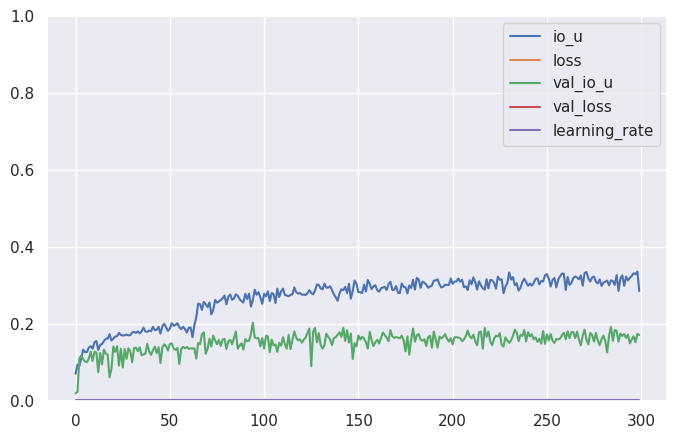

In [ ]:
#plotting training values
import seaborn as sns
sns.set()


pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:

IoU = history.history['IoU']
val_IoU = history.history['val_IoU']
epochs = range(1, len(IoU) + 1)

#accuracy plot
plt.plot(epochs, IoU, color='green', label='Training IoU')
plt.plot(epochs, val_IoU, color='blue', label='Validation IoU')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model (assuming it's in the current directory as 'model.keras')
# We need to provide the custom IoU metric when loading the model
model = load_model('model.keras')

# Define the path to the testing images
testpath = 'testing_images/'

# Get a list of all image files in the testing_images directory
test_image_files = gb.glob(testpath + '*.jpg') # Assuming images are .jpg

plt.figure(figsize=(20, 20))
for n, img_path in enumerate(test_image_files[:36]): # Display up to 36 images
    plt.subplot(6, 6, n + 1)

    # Read the original image
    original_img = cv2.imread(img_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    image_height, image_width, _ = original_img.shape

    # Resize the image for model prediction
    resized_image = cv2.resize(original_img_rgb, (new_size, new_size))

    # Expand dimensions to match model input shape (batch_size, height, width, channels)
    input_image = np.expand_dims(resized_image, axis=0)

    # Get prediction from the model
    region = model.predict(input_image)[0]

    # Scale the predicted bounding box coordinates back to the original image size
    x0 = int(region[0] * image_width / new_size)
    y0 = int(region[1] * image_height / new_size)
    x1 = int(region[2] * image_width / new_size)
    y1 = int(region[3] * image_height / new_size)

    # Draw the bounding box on the original image
    # cv2.rectangle expects (x1, y1) and (x2, y2) where (x2, y2) is the bottom-right corner
    # Ensure coordinates are within image bounds
    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(image_width, x1)
    y1 = min(image_height, y1)

    cv2.rectangle(original_img_rgb, (x0, y0), (x1, y1), (255, 0, 0), 2)

    plt.imshow(original_img_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#showing training images with predicted labels
plt.figure(figsize=(20,20))
# Iterate through the first 36 training images based on postion DataFrame
for n , i in enumerate(range(36)) :
    plt.subplot(6,6,n+1)

    # Read the original image from the training path using the image name from postion
    img_name = postion.iloc[i, 0] # Get image name from the first column of postion
    original_img = cv2.imread(trainpath + str(img_name))
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib

    image_height, image_width, _ = original_img.shape

    # Resize the image for model prediction (model was trained on new_size images)
    resized_image = cv2.resize(original_img_rgb, (new_size, new_size))

    # Expand dimensions to match model input shape (batch_size, height, width, channels)
    input_image = np.expand_dims(resized_image, axis=0)

    # Get prediction from the model
    region = model.predict(input_image)[0]

    # Scale the predicted bounding box coordinates back to the original image size
    x0 = int(region[0] * image_width / new_size)
    y0 = int(region[1] * image_height / new_size)
    x1 = int(region[2] * image_width / new_size)
    y1 = int(region[3] * image_height / new_size)

    # Ensure coordinates are within image bounds
    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(image_width, x1)
    y1 = min(image_height, y1)

    # Draw the bounding box on the original image (which is already RGB)
    cv2.rectangle(original_img_rgb, (x0, y0), (x1, y1) , (255,0,0),2)
    plt.imshow(original_img_rgb)
    plt.axis('off')

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
img=plt.imread('training_images/vid_4_1000.jpg')

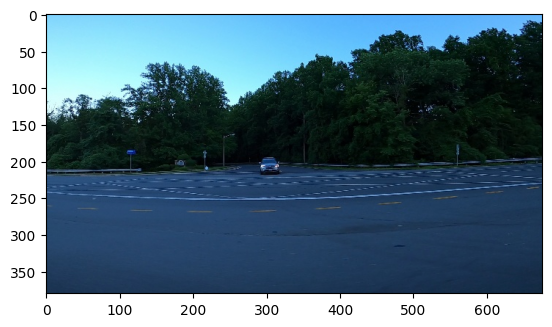

In [ ]:
plt.imshow(img)

In [ ]:
image_height, image_width, _ = img.shape
image = cv2.resize(img,(new_size,new_size))

In [ ]:
image.shape

(128, 128, 3)

In [ ]:
image=np.expand_dims(image,axis=0)

In [ ]:
region = model.predict(image)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [ ]:
region

array([52.698036, 63.58475 , 64.12288 , 77.47605 ], dtype=float32)

In [ ]:
x0 = int(region[0] * image_width / new_size)
y0 = int(region[1] * image_height / new_size)
x1 = int((region[2]) * image_width / new_size)
y1 = int((region[3]) * image_height / new_size)

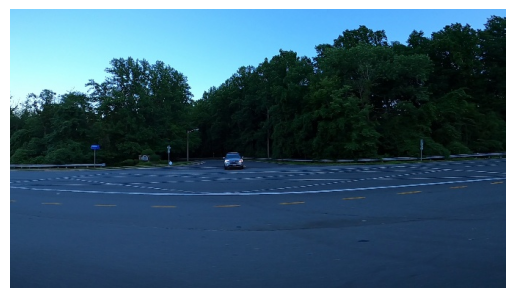

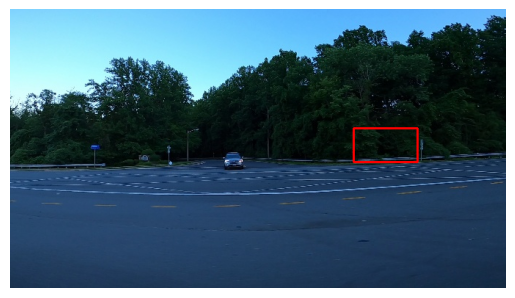

In [ ]:
# Display the image
img=plt.imread('training_images/vid_4_1000.jpg').copy() # Make a writable copy
plt.imshow(img)
plt.axis('off')
plt.show()
# Create a Rectangle patch
cv2.rectangle(img,(x0, y0), (x1 , y1) , (255,0,0),2) # Corrected second point

# Add the patch to the Axes
plt.imshow(img)
plt.axis('off')
plt.show()